In [1]:
from google.colab import files
upload = files.upload()

Saving juice_data.csv to juice_data.csv


In [31]:
import numpy as np
import pandas as pd


In [32]:
df= pd.read_csv("juice_data.csv", header = None )

In [33]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,98,99,100,101,102,103,104,105,106,107
0,NaN,NaN,NaN,NaN,"Phase in degrees,",pt. no.,0.0,1.000000,2.000000,3.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,decade points,0.0,0.080000,0.160000,0.240000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,Frequency,100.0,120.226444,144.543977,173.780083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,csv no.,Sr. No.,Sample_no.,Fruit,NaN,Time(min),NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E498x002.csv,1,1,Mosambi,Impedance,0,73.8,65.900000,59.000000,53.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# Drop columns from index 51 to 107 (inclusive)
df = df.drop(columns=df.columns[57:108])

In [35]:
df = df.iloc[4:].reset_index(drop=True)

In [36]:
columns = [
    "csv_no", "Sr_No", "Sample_no", "Fruit", "Type", "Time"
]

# Add frequency columns dynamically based on remaining columns
num_extra_cols = df.shape[1] - len(columns)

freq_cols = [f"F_{i}" for i in range(num_extra_cols)]

# Final column names
df.columns = columns + freq_cols

# Check result
print(df.head())

         csv_no Sr_No Sample_no    Fruit       Type Time   F_0   F_1   F_2  \
0  E498x002.csv     1         1  Mosambi  Impedance    0  73.8  65.9  59.0   
1  E498x002.csv     2         1  Mosambi      Phase    0 -58.8 -57.1 -55.0   
2  E498x003.csv     3         1  Mosambi  Impedance    2  77.7  70.2  63.8   
3  E498x003.csv     4         1  Mosambi      Phase    2 -53.4 -51.1 -48.5   
4  E498x004.csv     5         1  Mosambi  Impedance    4  79.2  71.5  64.8   

    F_3  ...   F_41   F_42   F_43   F_44   F_45   F_46   F_47   F_48   F_49  \
0  53.0  ...  23.60  23.60  23.60  23.60  23.60  23.60  23.60  23.60  23.70   
1 -52.5  ...  -0.12  -0.06   0.00   0.06   0.13   0.21   0.29   0.39   0.50   
2  58.2  ...  31.40  31.40  31.40  31.40  31.40  31.40  31.40  31.40  31.40   
3 -45.7  ...  -0.19  -0.15  -0.12  -0.09  -0.06  -0.03   0.00   0.04   0.07   
4  59.1  ...  31.50  31.50  31.50  31.50  31.50  31.50  31.50  31.60  31.60   

    F_50  
0  23.70  
1   0.63  
2  31.50  
3   0.11  
4

In [37]:
df = df.dropna(axis=1, how='all')

In [38]:
df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

In [39]:
df.head()

,csv_no,Sr_No,Sample_no,Fruit,Type,Time,F_0,F_1,F_2,F_3,...,F_41,F_42,F_43,F_44,F_45,F_46,F_47,F_48,F_49,F_50
0,E498x002.csv,1,1,Mosambi,Impedance,0.0,73.8,65.9,59.0,53.0,...,23.60,23.60,23.60,23.60,23.60,23.60,23.60,23.60,23.70,23.70
1,E498x002.csv,2,1,Mosambi,Phase,0.0,-58.8,-57.1,-55.0,-52.5,...,-0.12,-0.06,0.00,0.06,0.13,0.21,0.29,0.39,0.50,0.63
2,E498x003.csv,3,1,Mosambi,Impedance,2.0,77.7,70.2,63.8,58.2,...,31.40,31.40,31.40,31.40,31.40,31.40,31.40,31.40,31.40,31.50
3,E498x003.csv,4,1,Mosambi,Phase,2.0,-53.4,-51.1,-48.5,-45.7,...,-0.19,-0.15,-0.12,-0.09,-0.06,-0.03,0.00,0.04,0.07,0.11
4,E498x004.csv,5,1,Mosambi,Impedance,4.0,79.2,71.5,64.8,59.1,...,31.50,31.50,31.50,31.50,31.50,31.50,31.50,31.60,31.60,31.60


In [40]:
#df_t0 = df[df["Time"] == 0].reset_index(drop=True)
#df_t2 = df[df["Time"] == 2].reset_index(drop=True)
df_t4 = df[df["Time"] == 4].reset_index(drop=True)

#print("t=0 shape:", df_t0.shape)
#print("t=2 shape:", df_t2.shape)
print("t=4 shape:", df_t4.shape)

t=4 shape: (180, 57)


In [41]:
# Separate analysis on t=4
imp_df = df_t4[df_t4["Type"] == "Impedance"]
phase_df = df_t4[df_t4["Type"] == "Phase"]

In [42]:
drop_cols = ["csv_no", "Sr_No", "Sample_no", "Fruit", "Type", "Time"]

X_imp = imp_df.drop(columns=drop_cols)
y_imp = imp_df["Fruit"]

In [43]:
X_phase = phase_df.drop(columns=drop_cols)
y_phase = phase_df["Fruit"]

In [44]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

def apply_lda(X, y):
    X = X.fillna(X.mean())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    lda = LinearDiscriminantAnalysis(n_components=2)
    X_lda = lda.fit_transform(X_scaled, y)

    return X_lda

In [45]:
X_lda_imp = apply_lda(X_imp, y_imp)
X_lda_phase = apply_lda(X_phase, y_phase)

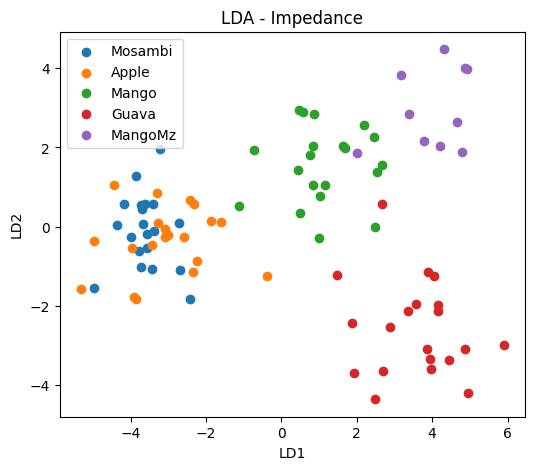

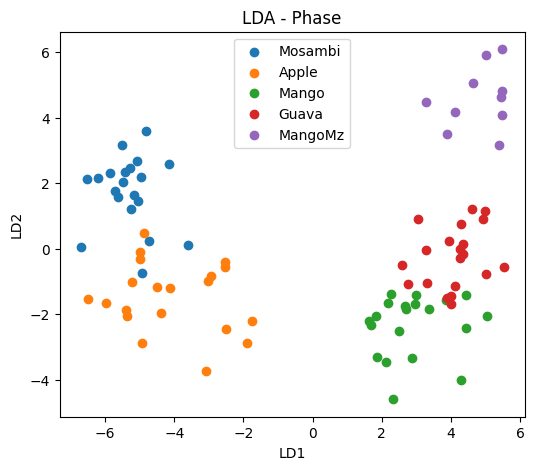

In [46]:
import matplotlib.pyplot as plt

def plot_lda(X_lda, y, title):
    plt.figure(figsize=(6,5))
    for label in y.unique():
        plt.scatter(
            X_lda[y == label, 0],
            X_lda[y == label, 1],
            label=label
        )
    plt.title(title)
    plt.xlabel("LD1")
    plt.ylabel("LD2")
    plt.legend()
    plt.show()

plot_lda(X_lda_imp, y_imp, "LDA - Impedance")
plot_lda(X_lda_phase, y_phase, "LDA - Phase")

In [47]:
import numpy as np

# Align rows (same order assumed)
Z = imp_df.drop(columns=drop_cols).values
phase = phase_df.drop(columns=drop_cols).values

# Convert degrees → radians
phase_rad = np.deg2rad(phase)

Zreal = Z * np.cos(phase_rad)
Zimag = Z * np.sin(phase_rad)

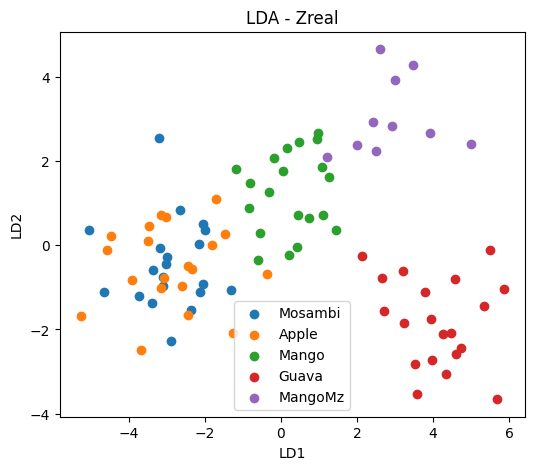

In [48]:
X_zreal = pd.DataFrame(Zreal)
y = imp_df["Fruit"]

X_lda_zreal = apply_lda(X_zreal, y)

plot_lda(X_lda_zreal, y, "LDA - Zreal")

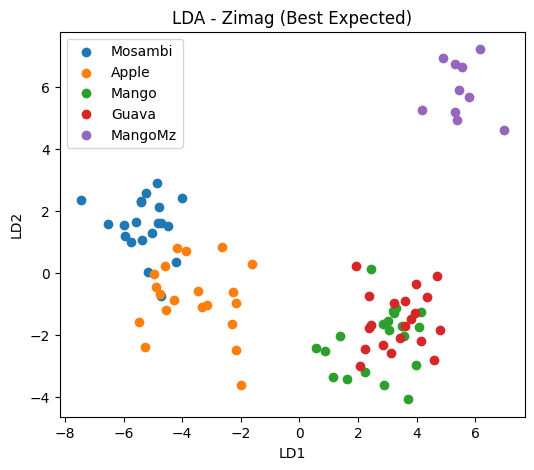

In [49]:
X_zimag = pd.DataFrame(Zimag)
y = imp_df["Fruit"]

X_lda_zimag = apply_lda(X_zimag, y)

plot_lda(X_lda_zimag, y, "LDA - Zimag (Best Expected)")

In [50]:
df_t4_merged = imp_df.merge(
    phase_df,
    on=["csv_no", "Sample_no", "Fruit", "Time"],
    suffixes=('_imp', '_phase')
)

# Define drop_cols specific to the merged dataframe, accounting for suffixes
drop_cols_for_X = [
    "csv_no", "Sr_No_imp", "Sr_No_phase", "Sample_no", "Fruit",
    "Type_imp", "Type_phase", "Time"
]

# Ensure we only drop columns that actually exist in df_t2_merged
X = df_t4_merged.drop(columns=[col for col in drop_cols_for_X if col in df_t4_merged.columns])
y = df_t4_merged["Fruit"]

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

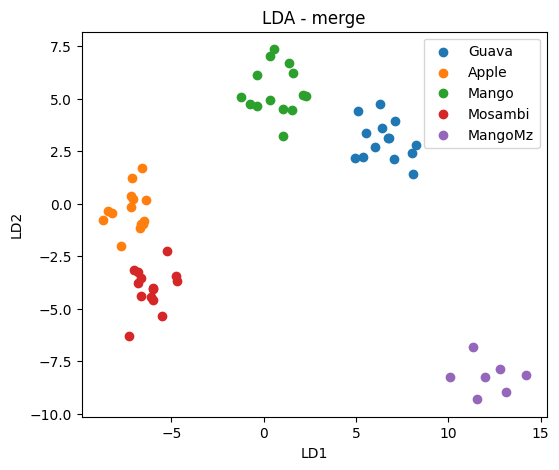

In [52]:
X_lda_merge = apply_lda(X_train, y_train)

plot_lda(X_lda_merge , y_train, "LDA - merge")

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lda_merge)

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn = KNeighborsClassifier()

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_scaled, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV Accuracy: 1.0


In [54]:
best_knn = grid.best_estimator_

best_knn.fit(X_scaled, y_train)


KNeighborsClassifier(metric='euclidean', n_neighbors=3)

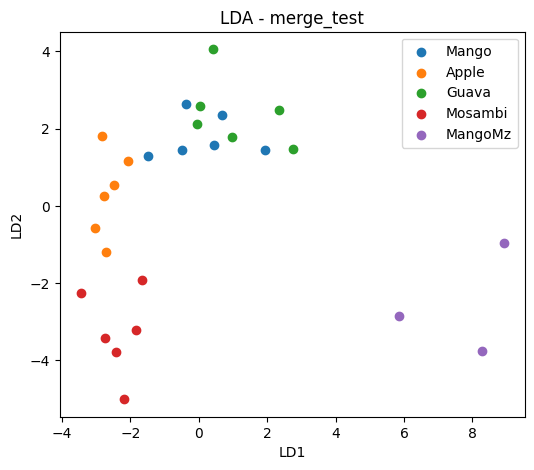

In [55]:
X_lda_merge_test = apply_lda(X_test, y_test)
plot_lda(X_lda_merge_test , y_test, "LDA - merge_test")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_test = scaler.fit_transform(X_lda_merge_test)
y_pred = best_knn.predict(X_scaled_test)

In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.7407407407407407

Classification Report:
               precision    recall  f1-score   support

       Apple       0.83      0.83      0.83         6
       Guava       0.67      0.33      0.44         6
       Mango       0.50      0.67      0.57         6
     MangoMz       1.00      1.00      1.00         3
     Mosambi       0.86      1.00      0.92         6

    accuracy                           0.74        27
   macro avg       0.77      0.77      0.75        27
weighted avg       0.75      0.74      0.73        27


Confusion Matrix:
 [[5 0 0 0 1]
 [0 2 4 0 0]
 [1 1 4 0 0]
 [0 0 0 3 0]
 [0 0 0 0 6]]
